# Imports

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Data Preprocessing

## Load dataset

The red wine and white wine datasets were loaded separately. Since both files use semicolons as separators, sep=";" was used when reading the CSV files.

In [121]:
# Load red wine and white wine datasets
red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";")

# Display the shape of each dataset
print("Red wine dataset shape:", red.shape)
print("White wine dataset shape:", white.shape)

# Display the first five rows of each dataset
print("Red wine samples:")
print(red.head())

print("\nWhite wine samples:")
print(white.head())

Red wine dataset shape: (1599, 12)
White wine dataset shape: (4898, 12)
Red wine samples:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56 

## Add a column to distinguish red wine and white *wine*

A new column named wine_type was added to distinguish red wine and white wine samples. The two datasets were then combined into one dataframe for further preprocessing and analysis.

In [122]:
# Add a new column to identify wine type
red["wine_type"] = "red"
white["wine_type"] = "white"

# Combine red and white wine datasets
df = pd.concat([red, white], axis=0, ignore_index=True)

# Display combined dataset information
print("Combined dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print(df.head())

Combined dataset shape: (6497, 13)
Number of rows: 6497
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality wine_type 

## Data inspection

The dataset information was checked to understand the number of columns, data types, and non-null values.

In [123]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


## Check missing values

Missing values were checked to ensure that the dataset was complete before model training.

In [124]:
# Check missing values in each column
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64


## Check duplicated rows

Duplicated rows were identified and removed to reduce repeated records in the dataset.

In [125]:
# Check duplicated rows
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 1177


Duplicated rows were identified and removed to reduce repeated records in the dataset.

In [126]:
# Remove duplicated rows
df = df.drop_duplicates()

# Check dataset size after removing duplicates
print("Dataset shape after removing duplicates:", df.shape)
print("Number of rows after removing duplicates:", df.shape[0])

Dataset shape after removing duplicates: (5320, 13)
Number of rows after removing duplicates: 5320


## Encode wine type

The wine_type column was encoded into numerical values because machine learning models require numerical input. Red wine was represented as 0, while white wine was represented as 1.

In [127]:
# Encode wine_type column
df["wine_type"] = df["wine_type"].map({
    "red": 0,
    "white": 1
})

# Check the result
print(df["wine_type"].value_counts())
print(df.head())

wine_type
1    3961
0    1359
Name: count, dtype: int64
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
5            7.4              0.66         0.00             1.8      0.075   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
5                 13.0                  40.0   0.9978  3.51       0.56   

   alcohol  quality  wine_type

## Check target variable distribution

The target variable distribution was analysed separately for red wine and white wine instead of using only the combined dataset. This approach provides a clearer understanding of the quality score patterns for each wine type. The results were presented using frequency counts and bar charts.

### Check target variable distribution for red wine

Red wine quality distribution:
quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


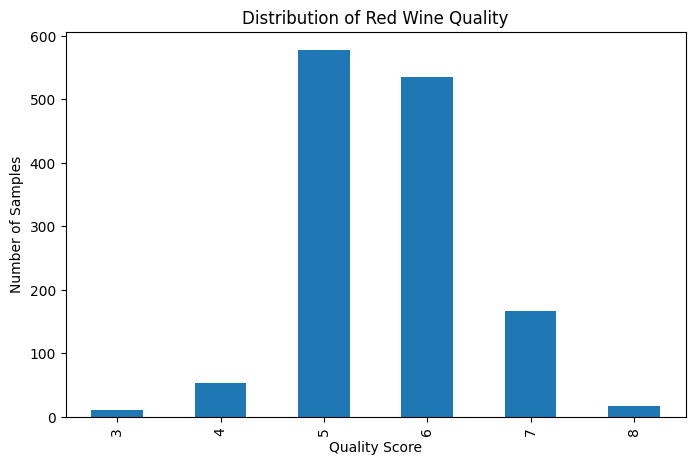

In [128]:
# Check red wine quality distribution
print("Red wine quality distribution:")
print(df[df["wine_type"] == 0]["quality"].value_counts().sort_index())

# Plot red wine quality distribution
plt.figure(figsize=(8,5))
df[df["wine_type"] == 0]["quality"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Red Wine Quality")
plt.xlabel("Quality Score")
plt.ylabel("Number of Samples")
plt.show()

### Check target variable distribution for white wine

White wine quality distribution:
quality
3      20
4     153
5    1175
6    1788
7     689
8     131
9       5
Name: count, dtype: int64


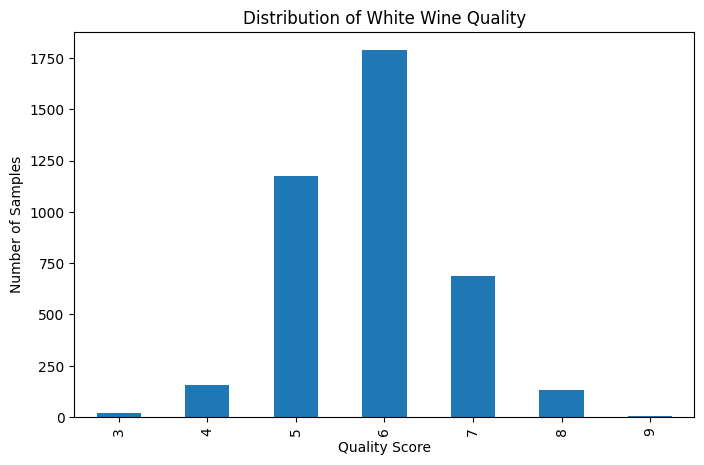

In [129]:
# Check white wine quality distribution
print("White wine quality distribution:")
print(df[df["wine_type"] == 1]["quality"].value_counts().sort_index())

# Plot white wine quality distribution
plt.figure(figsize=(8,5))
df[df["wine_type"] == 1]["quality"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of White Wine Quality")
plt.xlabel("Quality Score")
plt.ylabel("Number of Samples")
plt.show()

## Train-Validation-Test Split

The dataset was split into training, validation, and testing sets using a 50:30:20 ratio. A combined stratification label was created using both quality and wine_type to maintain similar quality score distributions and red/white wine proportions across the three datasets.

In [130]:
# Separate input features and target variable
X = df.drop("quality", axis=1)
y = df["quality"]

# Create a combined stratification label using quality and wine_type
stratify_col = df["quality"].astype(str) + "_" + df["wine_type"].astype(str)

# First split: 50% training set and 50% temporary set
X_train, X_temp, y_train, y_temp, strat_train, strat_temp = train_test_split(
    X, y, stratify_col,
    test_size=0.5,
    random_state=42,
    stratify=stratify_col
)

# Second split: split the temporary set into validation set and testing set
# Validation set = 30% of the whole dataset
# Testing set = 20% of the whole dataset
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.4,
    random_state=42,
    stratify=strat_temp
)

# Display dataset shapes
print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (2660, 12)
Validation set shape: (1596, 12)
Testing set shape: (1064, 12)


### Check Wine Type Distribution in Each Dataset

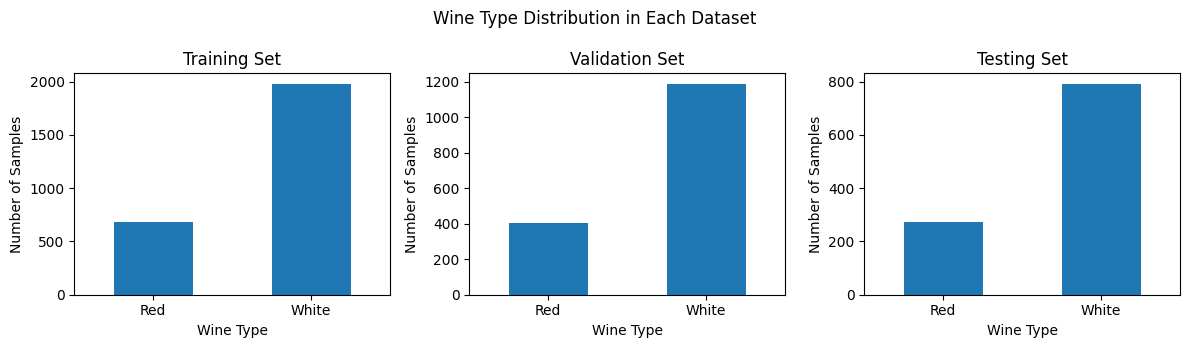

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3.5))

# Training set
plt.subplot(1, 3, 1)
X_train["wine_type"].value_counts().sort_index().plot(kind="bar")
plt.title("Training Set")
plt.xlabel("Wine Type")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ["Red", "White"], rotation=0)

# Validation set
plt.subplot(1, 3, 2)
X_val["wine_type"].value_counts().sort_index().plot(kind="bar")
plt.title("Validation Set")
plt.xlabel("Wine Type")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ["Red", "White"], rotation=0)

# Testing set
plt.subplot(1, 3, 3)
X_test["wine_type"].value_counts().sort_index().plot(kind="bar")
plt.title("Testing Set")
plt.xlabel("Wine Type")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ["Red", "White"], rotation=0)

plt.suptitle("Wine Type Distribution in Each Dataset")
plt.tight_layout()
plt.show()

### Quality Distribution in Each Dataset

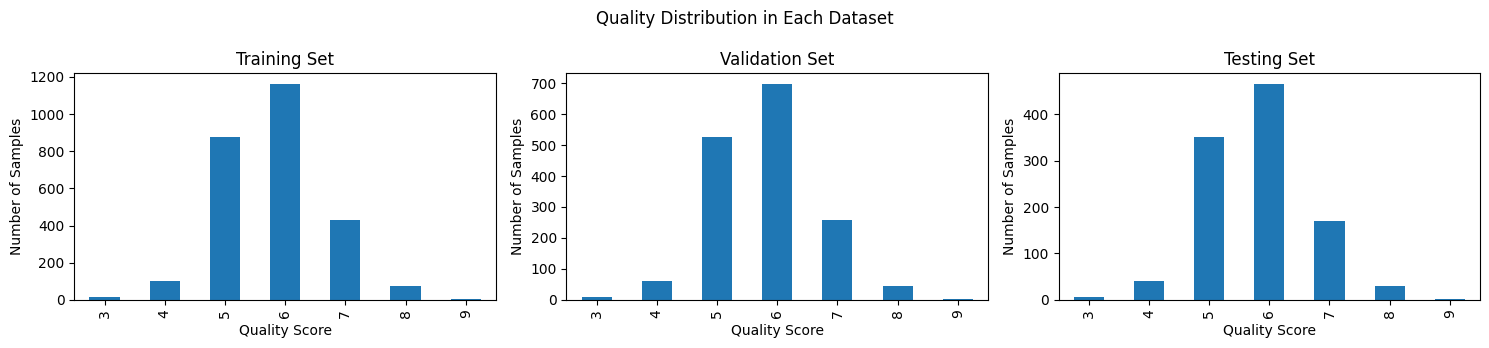

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 3.5))

# Training set
plt.subplot(1, 3, 1)
y_train.value_counts().sort_index().plot(kind="bar")
plt.title("Training Set")
plt.xlabel("Quality Score")
plt.ylabel("Number of Samples")

# Validation set
plt.subplot(1, 3, 2)
y_val.value_counts().sort_index().plot(kind="bar")
plt.title("Validation Set")
plt.xlabel("Quality Score")
plt.ylabel("Number of Samples")

# Testing set
plt.subplot(1, 3, 3)
y_test.value_counts().sort_index().plot(kind="bar")
plt.title("Testing Set")
plt.xlabel("Quality Score")
plt.ylabel("Number of Samples")

plt.suptitle("Quality Distribution in Each Dataset")
plt.tight_layout()
plt.show()

## Feature Standardization

Feature standardization was applied after splitting the dataset to avoid data leakage. The scaler was fitted only on the training set and then applied to the validation and testing sets. The wine_type variable was not standardized because it is an encoded categorical variable. Standardization helps ensure that numerical features with different scales contribute more fairly to model training.

In [133]:
from sklearn.preprocessing import StandardScaler

# Copy the datasets
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

# Select numerical features, excluding wine_type
numeric_features = X_train.columns.drop("wine_type")

# Apply standardization only to numerical features
scaler = StandardScaler()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_val_scaled[numeric_features] = scaler.transform(X_val[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

# Display the first few rows after standardization
print("Standardization completed.")
print(X_train_scaled.head())

Standardization completed.
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
4119       0.198747          0.393315    -0.587641        2.187743  -0.070846   
3102      -0.324168          0.096187    -0.520910       -0.099553  -0.468476   
1501       0.422854          2.829769    -0.187250       -0.166826   0.697906   
5737      -0.473573         -0.676347     0.012945       -0.794711  -0.415459   
1521      -0.249466          0.809295    -0.787837       -0.705014   0.671397   

      free sulfur dioxide  total sulfur dioxide   density        pH  \
4119            -0.117822              1.078111  1.520411 -0.281579   
3102            -0.349675              0.188128 -1.240312  0.281908   
1501            -0.523564             -0.879852  0.645727 -0.406798   
5737            -1.277086             -0.737455 -1.722072 -0.031140   
1521            -1.219123             -1.609639  0.450973  1.033224   

      sulphates   alcohol  wine_type  
4119  -0.274823 -0.7

# Method 1: Ordinal Regression


In [134]:
# ORDINAL REGRESSION - Wine Quality Modeling

# Install mord (ordinal regression library)
!pip install mord -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mord import LogisticIT
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, classification_report,
                             mean_absolute_error)

## Train Ordinal Regression Model

In [135]:
# LogisticIT = Logistic Immediate Threshold (standard ordinal regression)
# alpha = regularization strength (tuned via validation set)

model_ordinal = LogisticIT(alpha=1.0)
model_ordinal.fit(X_train_scaled, y_train)

print("Ordinal Regression model trained successfully.")
print(f"Classes: {model_ordinal.classes_}")

Ordinal Regression model trained successfully.
Classes: [3 4 5 6 7 8 9]


## Hyperparameter Tuning

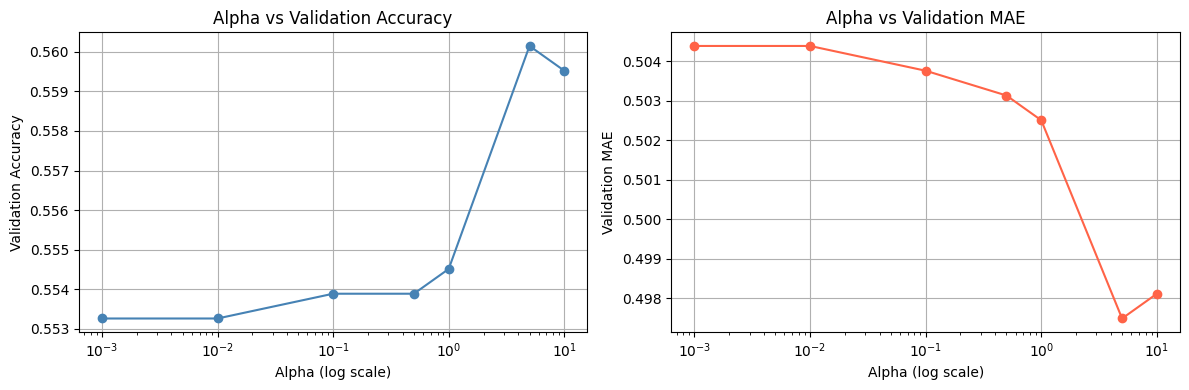


Best alpha: 5.0
Best validation accuracy: 0.5602


In [136]:
# Using Validation Set
alpha_values = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
val_accuracies = []
val_maes = []

for alpha in alpha_values:
    m = LogisticIT(alpha=alpha)
    m.fit(X_train_scaled, y_train)
    y_pred_val = m.predict(X_val_scaled)
    val_accuracies.append(accuracy_score(y_val, y_pred_val))
    val_maes.append(mean_absolute_error(y_val, y_pred_val))

# Plot tuning results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(alpha_values, val_accuracies, marker='o', color='steelblue')
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Alpha vs Validation Accuracy')
axes[0].grid(True)

axes[1].plot(alpha_values, val_maes, marker='o', color='tomato')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('Validation MAE')
axes[1].set_title('Alpha vs Validation MAE')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Select best alpha based on highest validation accuracy
best_alpha = alpha_values[np.argmax(val_accuracies)]
print(f"\nBest alpha: {best_alpha}")
print(f"Best validation accuracy: {max(val_accuracies):.4f}")

## Retrain with Best Alpha and Evaluate on Test Set

In [137]:
# Retrain with best alpha
model_ordinal = LogisticIT(alpha=best_alpha)
model_ordinal.fit(X_train_scaled, y_train)

# Predict
y_pred_train = model_ordinal.predict(X_train_scaled)
y_pred_val   = model_ordinal.predict(X_val_scaled)
y_pred_test  = model_ordinal.predict(X_test_scaled)

# --- Accuracy ---
train_acc = accuracy_score(y_train, y_pred_train)
val_acc   = accuracy_score(y_val,   y_pred_val)
test_acc  = accuracy_score(y_test,  y_pred_test)

# --- F1 Score (weighted) ---
train_f1 = f1_score(y_train, y_pred_train, average='weighted')
val_f1   = f1_score(y_val,   y_pred_val,   average='weighted')
test_f1  = f1_score(y_test,  y_pred_test,  average='weighted')

# --- MAE (ordinal-specific metric) ---
train_mae = mean_absolute_error(y_train, y_pred_train)
val_mae   = mean_absolute_error(y_val,   y_pred_val)
test_mae  = mean_absolute_error(y_test,  y_pred_test)

print("=" * 50)
print("ORDINAL REGRESSION - EVALUATION RESULTS")
print("=" * 50)
print(f"{'Set':<12} {'Accuracy':>10} {'F1 (weighted)':>15} {'MAE':>8}")
print("-" * 50)
print(f"{'Train':<12} {train_acc:>10.4f} {train_f1:>15.4f} {train_mae:>8.4f}")
print(f"{'Validation':<12} {val_acc:>10.4f} {val_f1:>15.4f} {val_mae:>8.4f}")
print(f"{'Test':<12} {test_acc:>10.4f} {test_f1:>15.4f} {test_mae:>8.4f}")
print("=" * 50)

ORDINAL REGRESSION - EVALUATION RESULTS
Set            Accuracy   F1 (weighted)      MAE
--------------------------------------------------
Train            0.5440          0.5062   0.5071
Validation       0.5602          0.5232   0.4975
Test             0.5385          0.5036   0.5169


## Confusion Matrix

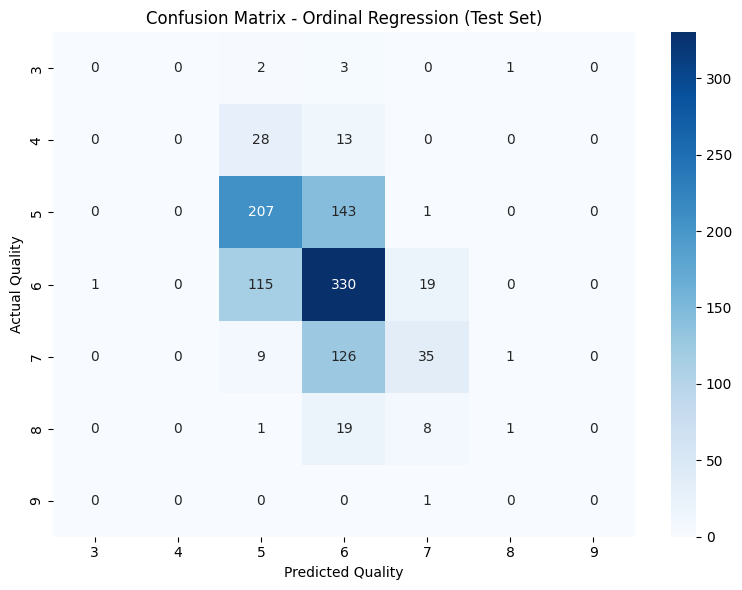

In [138]:
cm = confusion_matrix(y_test, y_pred_test)
classes = sorted(y_test.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - Ordinal Regression (Test Set)')
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.tight_layout()
plt.show()

## Classification Report

In [139]:
print("Classification Report - Ordinal Regression (Test Set)")
print("=" * 60)
print(classification_report(y_test, y_pred_test))

Classification Report - Ordinal Regression (Test Set)
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        41
           5       0.57      0.59      0.58       351
           6       0.52      0.71      0.60       465
           7       0.55      0.20      0.30       171
           8       0.33      0.03      0.06        29
           9       0.00      0.00      0.00         1

    accuracy                           0.54      1064
   macro avg       0.28      0.22      0.22      1064
weighted avg       0.51      0.54      0.50      1064



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Prediction Error Distribution

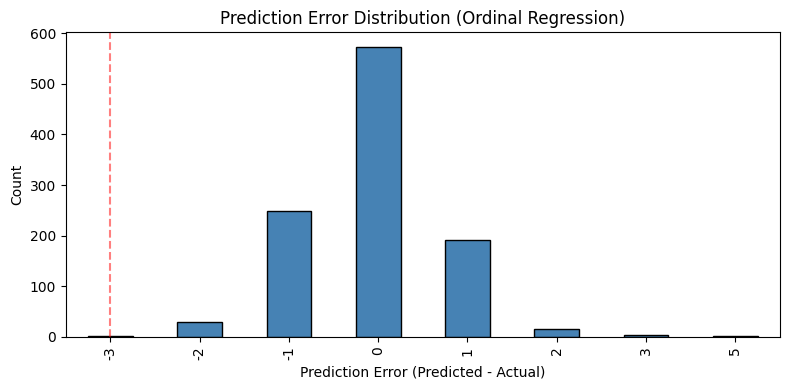


Exact match rate: 0.5385
Within 1 grade: 0.9521
Within 2 grades: 0.9944


In [140]:
errors = y_pred_test - y_test.values
plt.figure(figsize=(8, 4))
pd.Series(errors).value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Prediction Error Distribution (Ordinal Regression)')
plt.xlabel('Prediction Error (Predicted - Actual)')
plt.ylabel('Count')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\nExact match rate: {(errors == 0).mean():.4f}")
print(f"Within 1 grade: {(np.abs(errors) <= 1).mean():.4f}")
print(f"Within 2 grades: {(np.abs(errors) <= 2).mean():.4f}")

# Method 2: Random Forest Classifier

In [141]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, classification_report,
                             mean_absolute_error)

# Train Model

In [142]:
# RandomForestClassifier treats wine quality as ordered classes
# n_estimators = number of trees in the forest
# random_state = ensures reproducibility

model_rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model_rf.fit(X_train_scaled, y_train)

print("Random Forest Classifier model trained successfully.")
print(f"Number of features used: {model_rf.n_features_in_}")
print(f"Classes: {model_rf.classes_}")

Random Forest Classifier model trained successfully.
Number of features used: 12
Classes: [3 4 5 6 7 8 9]


# Hyperparameter Tuning

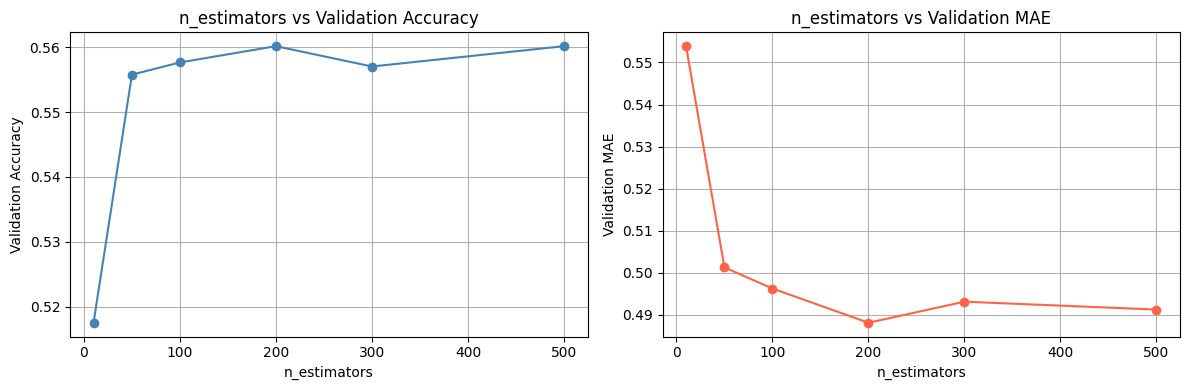


Best n_estimators: 200
Best validation accuracy: 0.5602


In [143]:
# Tune n_estimators using the validation set
# More trees generally reduce variance, but with diminishing returns

n_estimators_values = [10, 50, 100, 200, 300, 500]
val_accuracies_rf = []
val_maes_rf = []

for n in n_estimators_values:
    m = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    m.fit(X_train_scaled, y_train)
    y_pred_val = m.predict(X_val_scaled)
    val_accuracies_rf.append(accuracy_score(y_val, y_pred_val))
    val_maes_rf.append(mean_absolute_error(y_val, y_pred_val))

# Plot tuning results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(n_estimators_values, val_accuracies_rf, marker='o', color='steelblue')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('n_estimators vs Validation Accuracy')
axes[0].grid(True)

axes[1].plot(n_estimators_values, val_maes_rf, marker='o', color='tomato')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Validation MAE')
axes[1].set_title('n_estimators vs Validation MAE')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Select best n_estimators based on highest validation accuracy
best_n = n_estimators_values[np.argmax(val_accuracies_rf)]
print(f"\nBest n_estimators: {best_n}")
print(f"Best validation accuracy: {max(val_accuracies_rf):.4f}")

# Retrain with best n_estimators + evaluate

In [144]:
# Retrain with best n_estimators found from validation tuning
model_rf = RandomForestClassifier(n_estimators=best_n, random_state=42, n_jobs=-1)
model_rf.fit(X_train_scaled, y_train)

# Predict on all sets
y_pred_train = model_rf.predict(X_train_scaled)
y_pred_val   = model_rf.predict(X_val_scaled)
y_pred_test  = model_rf.predict(X_test_scaled)

# --- Accuracy ---
train_acc = accuracy_score(y_train, y_pred_train)
val_acc   = accuracy_score(y_val,   y_pred_val)
test_acc  = accuracy_score(y_test,  y_pred_test)

# --- F1 Score (weighted) ---
train_f1 = f1_score(y_train, y_pred_train, average='weighted')
val_f1   = f1_score(y_val,   y_pred_val,   average='weighted')
test_f1  = f1_score(y_test,  y_pred_test,  average='weighted')

# --- MAE ---
train_mae = mean_absolute_error(y_train, y_pred_train)
val_mae   = mean_absolute_error(y_val,   y_pred_val)
test_mae  = mean_absolute_error(y_test,  y_pred_test)

print("=" * 60)
print("RANDOM FOREST CLASSIFIER - EVALUATION RESULTS")
print("=" * 60)
print(f"{'Set':<12} {'Accuracy':>10} {'F1 (weighted)':>15} {'MAE':>8}")
print("-" * 60)
print(f"{'Train':<12} {train_acc:>10.4f} {train_f1:>15.4f} {train_mae:>8.4f}")
print(f"{'Validation':<12} {val_acc:>10.4f} {val_f1:>15.4f} {val_mae:>8.4f}")
print(f"{'Test':<12} {test_acc:>10.4f} {test_f1:>15.4f} {test_mae:>8.4f}")
print("=" * 60)

RANDOM FOREST CLASSIFIER - EVALUATION RESULTS
Set            Accuracy   F1 (weighted)      MAE
------------------------------------------------------------
Train            1.0000          1.0000   0.0000
Validation       0.5602          0.5350   0.4881
Test             0.5555          0.5314   0.4859


# Confusion Matrix

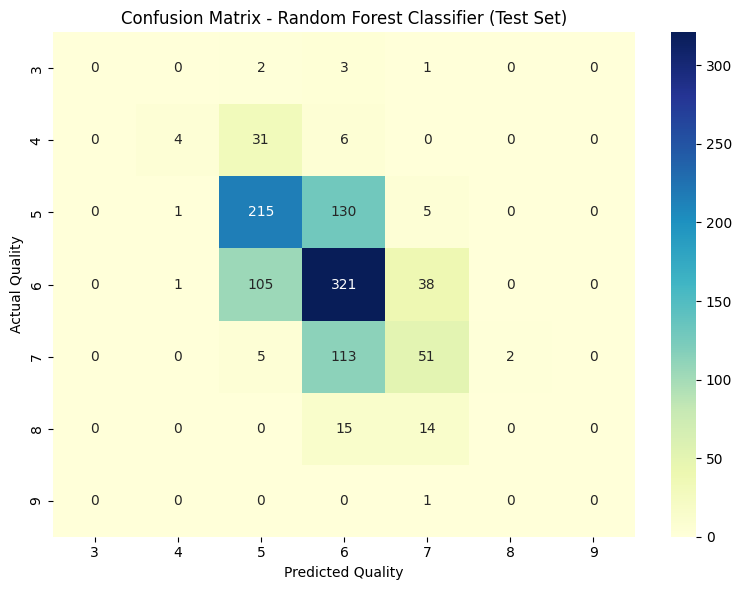

In [145]:
cm = confusion_matrix(y_test, y_pred_test)
classes = sorted(y_test.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - Random Forest Classifier (Test Set)')
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.tight_layout()
plt.show()

# Classification report + error distribution

Classification Report - Random Forest Classifier (Test Set)
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.67      0.10      0.17        41
           5       0.60      0.61      0.61       351
           6       0.55      0.69      0.61       465
           7       0.46      0.30      0.36       171
           8       0.00      0.00      0.00        29
           9       0.00      0.00      0.00         1

    accuracy                           0.56      1064
   macro avg       0.33      0.24      0.25      1064
weighted avg       0.54      0.56      0.53      1064



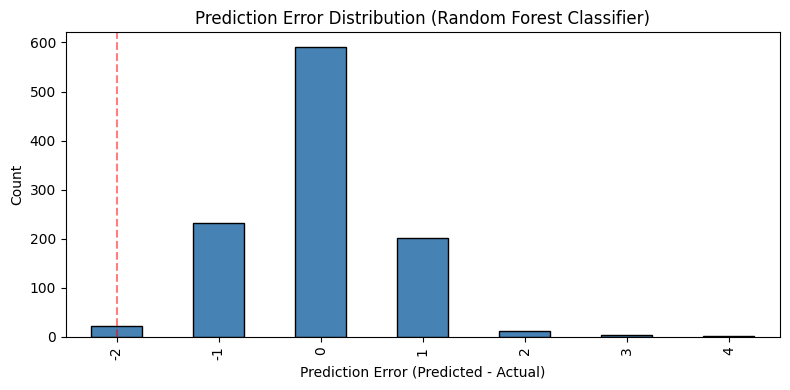


Exact match rate: 0.5555
Within 1 grade:   0.9633
Within 2 grades:  0.9962


In [146]:
print("Classification Report - Random Forest Classifier (Test Set)")
print("=" * 60)
print(classification_report(y_test, y_pred_test, zero_division=0))

# Prediction error distribution
errors = y_pred_test - y_test.values
plt.figure(figsize=(8, 4))
pd.Series(errors).value_counts().sort_index().plot(
    kind='bar', color='steelblue', edgecolor='black')
plt.title('Prediction Error Distribution (Random Forest Classifier)')
plt.xlabel('Prediction Error (Predicted - Actual)')
plt.ylabel('Count')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\nExact match rate: {(errors == 0).mean():.4f}")
print(f"Within 1 grade:   {(np.abs(errors) <= 1).mean():.4f}")
print(f"Within 2 grades:  {(np.abs(errors) <= 2).mean():.4f}")

# Method 3: Multi-Layer Perceptron(MLP)

## Hyperparameter Tuning

Tuning MLP hyperparameters, please wait...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


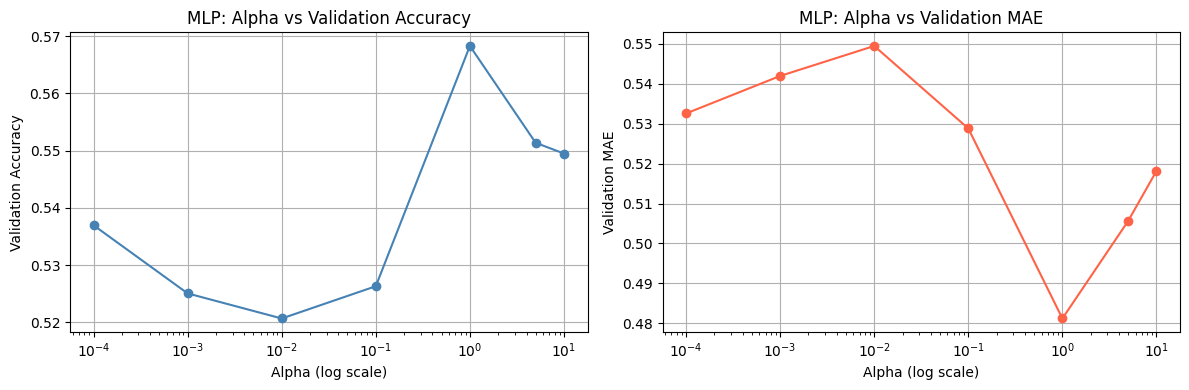


Best alpha: 1.0
Best validation accuracy: 0.5683


In [147]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, classification_report,
                             mean_absolute_error)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Tune MLP's alpha (L2 regularization strength) using the validation set
# alpha controls overfitting — higher alpha = stronger regularization
# Architecture: 2 hidden layers (50, 25 neurons) with ReLU activation
# ReLU is chosen over logistic/sigmoid because it avoids vanishing gradients
# and trains faster on multi-class classification problems

alpha_values = [0.0001, 0.001, 0.01, 0.1, 1.0, 5.0, 10.0]
val_accuracies_mlp = []
val_maes_mlp = []

print("Tuning MLP hyperparameters, please wait...")
for alpha in alpha_values:
    m = MLPClassifier(
        hidden_layer_sizes=(50, 25),
        activation='relu',
        max_iter=500,
        alpha=alpha,
        random_state=42
    )
    m.fit(X_train_scaled, y_train)
    y_pred_val = m.predict(X_val_scaled)
    val_accuracies_mlp.append(accuracy_score(y_val, y_pred_val))
    val_maes_mlp.append(mean_absolute_error(y_val, y_pred_val))

# Plot tuning results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(alpha_values, val_accuracies_mlp, marker='o', color='steelblue')
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('MLP: Alpha vs Validation Accuracy')
axes[0].grid(True)

axes[1].plot(alpha_values, val_maes_mlp, marker='o', color='tomato')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('Validation MAE')
axes[1].set_title('MLP: Alpha vs Validation MAE')
axes[1].grid(True)

plt.tight_layout()
plt.show()

best_alpha_mlp = alpha_values[np.argmax(val_accuracies_mlp)]
print(f"\nBest alpha: {best_alpha_mlp}")
print(f"Best validation accuracy: {max(val_accuracies_mlp):.4f}")

## Retrain with Best Alpha and Evaluate on Test Set

In [148]:
# Retrain MLP with the best alpha found from validation tuning
# early_stopping=True halts training when validation loss stops improving,
# preventing overfitting without needing to manually set max_iter

model_mlp = MLPClassifier(
    hidden_layer_sizes=(50, 25),
    activation='relu',
    max_iter=500,
    alpha=best_alpha_mlp,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
model_mlp.fit(X_train_scaled, y_train)

# Check convergence
if model_mlp.n_iter_ < 500:
    print(f"Model converged after {model_mlp.n_iter_} iterations.")
else:
    print("Warning: model reached max_iter without converging. Consider increasing max_iter.")

# Predict on all sets
y_pred_train = model_mlp.predict(X_train_scaled)
y_pred_val   = model_mlp.predict(X_val_scaled)
y_pred_test  = model_mlp.predict(X_test_scaled)

# --- Accuracy ---
train_acc = accuracy_score(y_train, y_pred_train)
val_acc   = accuracy_score(y_val,   y_pred_val)
test_acc  = accuracy_score(y_test,  y_pred_test)

# --- F1 Score (weighted) ---
train_f1 = f1_score(y_train, y_pred_train, average='weighted')
val_f1   = f1_score(y_val,   y_pred_val,   average='weighted')
test_f1  = f1_score(y_test,  y_pred_test,  average='weighted')

# --- MAE ---
train_mae = mean_absolute_error(y_train, y_pred_train)
val_mae   = mean_absolute_error(y_val,   y_pred_val)
test_mae  = mean_absolute_error(y_test,  y_pred_test)

print("=" * 50)
print("MLP NEURAL NETWORK - EVALUATION RESULTS")
print("=" * 50)
print(f"{'Set':<12} {'Accuracy':>10} {'F1 (weighted)':>15} {'MAE':>8}")
print("-" * 50)
print(f"{'Train':<12} {train_acc:>10.4f} {train_f1:>15.4f} {train_mae:>8.4f}")
print(f"{'Validation':<12} {val_acc:>10.4f} {val_f1:>15.4f} {val_mae:>8.4f}")
print(f"{'Test':<12} {test_acc:>10.4f} {test_f1:>15.4f} {test_mae:>8.4f}")
print("=" * 50)

Model converged after 28 iterations.
MLP NEURAL NETWORK - EVALUATION RESULTS
Set            Accuracy   F1 (weighted)      MAE
--------------------------------------------------
Train            0.5598          0.5271   0.4914
Validation       0.5508          0.5152   0.5044
Test             0.5536          0.5228   0.4925


## Confusion Matrix & Classification Report

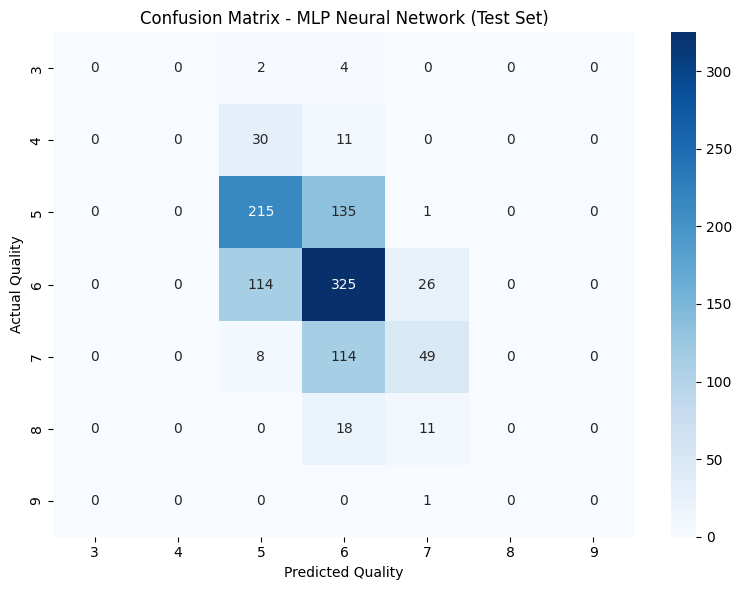

Classification Report - MLP Neural Network (Test Set)
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        41
           5       0.58      0.61      0.60       351
           6       0.54      0.70      0.61       465
           7       0.56      0.29      0.38       171
           8       0.00      0.00      0.00        29
           9       0.00      0.00      0.00         1

    accuracy                           0.55      1064
   macro avg       0.24      0.23      0.23      1064
weighted avg       0.52      0.55      0.52      1064



In [149]:
cm = confusion_matrix(y_test, y_pred_test)
classes = sorted(y_test.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - MLP Neural Network (Test Set)')
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.tight_layout()
plt.show()

print("Classification Report - MLP Neural Network (Test Set)")
print("=" * 60)
print(classification_report(y_test, y_pred_test, zero_division=0))

## Prediction Error Distribution

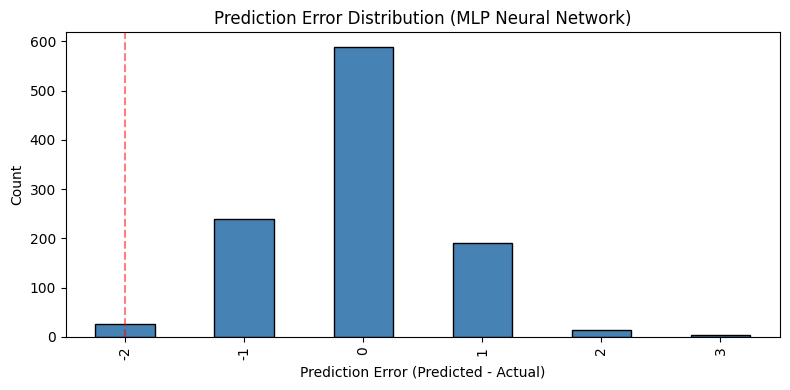


Exact match rate: 0.5536
Within 1 grade:   0.9577
Within 2 grades:  0.9962


In [150]:
# Prediction error distribution shows whether the model
# tends to overestimate or underestimate wine quality scores

errors = y_pred_test - y_test.values

plt.figure(figsize=(8, 4))
pd.Series(errors).value_counts().sort_index().plot(
    kind='bar', color='steelblue', edgecolor='black')
plt.title('Prediction Error Distribution (MLP Neural Network)')
plt.xlabel('Prediction Error (Predicted - Actual)')
plt.ylabel('Count')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\nExact match rate: {(errors == 0).mean():.4f}")
print(f"Within 1 grade:   {(np.abs(errors) <= 1).mean():.4f}")
print(f"Within 2 grades:  {(np.abs(errors) <= 2).mean():.4f}")

# Feature Importance Plot

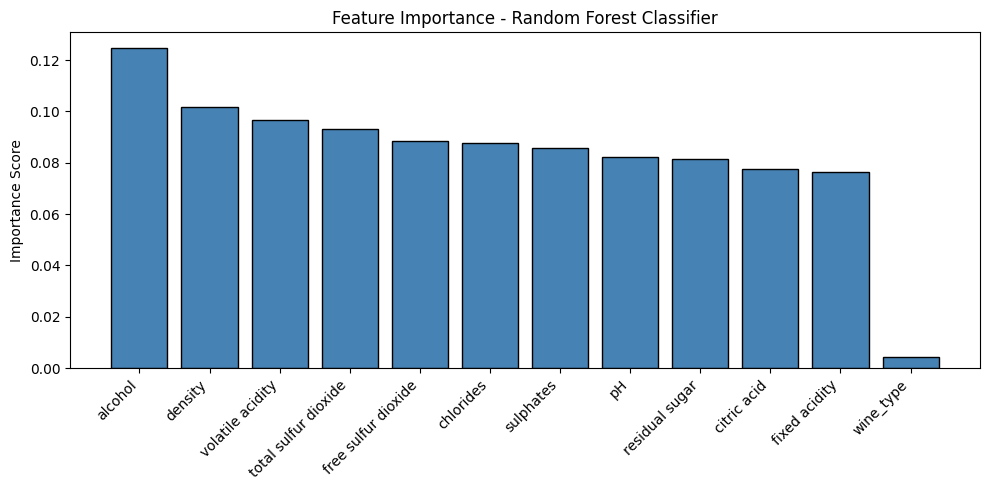

Feature importance ranking:
   1. alcohol                        0.1246
   2. density                        0.1016
   3. volatile acidity               0.0966
   4. total sulfur dioxide           0.0932
   5. free sulfur dioxide            0.0884
   6. chlorides                      0.0876
   7. sulphates                      0.0858
   8. pH                             0.0823
   9. residual sugar                 0.0815
  10. citric acid                    0.0776
  11. fixed acidity                  0.0765
  12. wine_type                      0.0044


In [151]:
# Feature importance shows which physicochemical properties
# have the greatest influence on wine quality prediction

feature_names = X_train.columns.tolist()
importances = model_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_names)),
        importances[indices],
        color='steelblue', edgecolor='black')
plt.xticks(range(len(feature_names)),
           [feature_names[i] for i in indices],
           rotation=45, ha='right')
plt.title('Feature Importance - Random Forest Classifier')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print("Feature importance ranking:")
for rank, i in enumerate(indices):
    print(f"  {rank+1:>2}. {feature_names[i]:<30} {importances[i]:.4f}")

# Oveall Comparison

OVERALL MODEL COMPARISON - TEST SET
                    Accuracy  F1 (weighted)    MAE  Within 1
Model                                                       
Ordinal Regression    0.5385         0.5036 0.5169    0.9521
Random Forest         0.5555         0.5314 0.4859    0.9633
MLP Neural Network    0.5536         0.5228 0.4925    0.9577


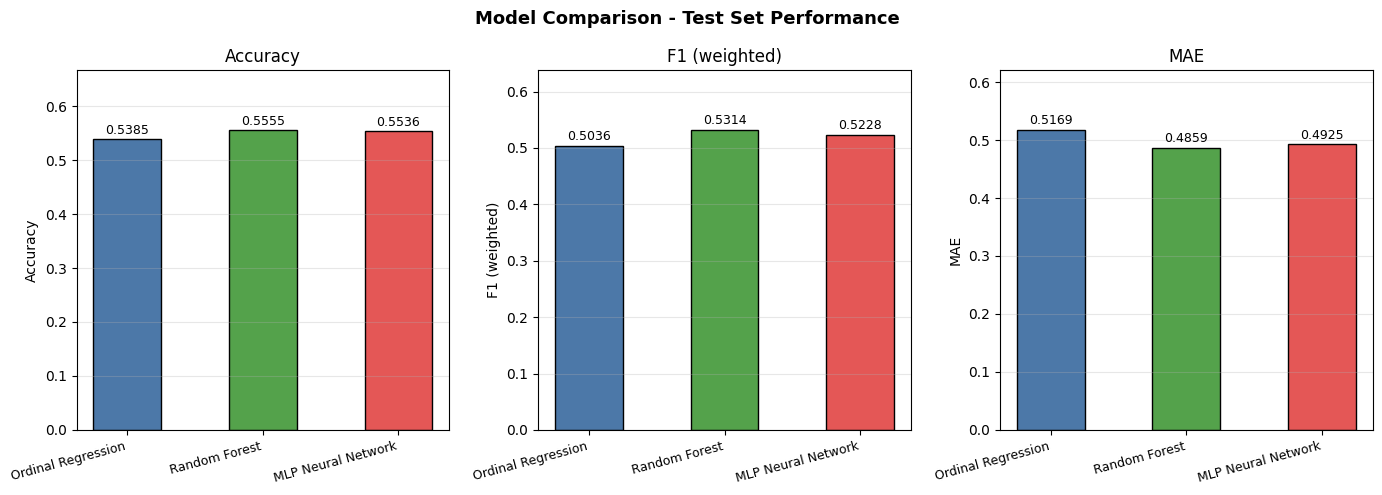

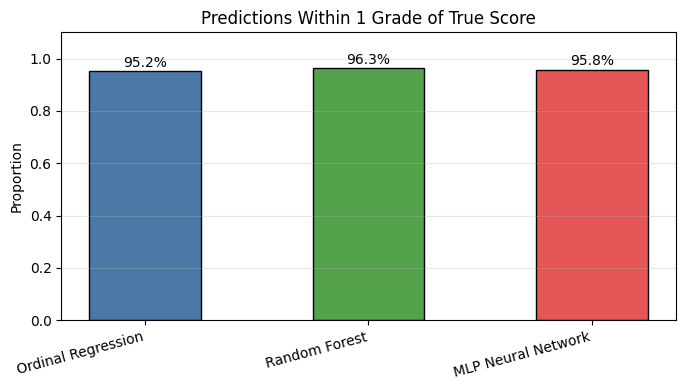

In [152]:
# ============================================================
# OVERALL MODEL COMPARISON
# ============================================================
# Collect results from all 3 models on the TEST set

# --- Ordinal Regression predictions (re-predict to be safe) ---
y_pred_ordinal = model_ordinal.predict(X_test_scaled)

# --- Random Forest predictions ---
y_pred_rf = model_rf.predict(X_test_scaled)

# --- MLP predictions ---
y_pred_mlp = model_mlp.predict(X_test_scaled)

# --- Compute metrics for each model ---
models = ['Ordinal Regression', 'Random Forest', 'MLP Neural Network']
preds  = [y_pred_ordinal, y_pred_rf, y_pred_mlp]

results = []
for name, pred in zip(models, preds):
    results.append({
        'Model':    name,
        'Accuracy': accuracy_score(y_test, pred),
        'F1 (weighted)': f1_score(y_test, pred, average='weighted'),
        'MAE':      mean_absolute_error(y_test, pred),
        'Within 1': (np.abs(pred - y_test.values) <= 1).mean()
    })

df_results = pd.DataFrame(results).set_index('Model')

print("=" * 70)
print("OVERALL MODEL COMPARISON - TEST SET")
print("=" * 70)
print(df_results.to_string(float_format='{:.4f}'.format))
print("=" * 70)

# --- Bar chart comparison ---
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['#4C78A8', '#54A24B', '#E45756']

metrics = ['Accuracy', 'F1 (weighted)', 'MAE']
for ax, metric in zip(axes, metrics):
    values = df_results[metric].values
    bars = ax.bar(models, values, color=colors, edgecolor='black', width=0.5)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_ylim(0, max(values) * 1.2)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Comparison - Test Set Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Within-1-grade comparison ---
plt.figure(figsize=(7, 4))
within1_vals = df_results['Within 1'].values
bars = plt.bar(models, within1_vals, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, within1_vals):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.1%}', ha='center', va='bottom', fontsize=10)
plt.title('Predictions Within 1 Grade of True Score')
plt.ylabel('Proportion')
plt.ylim(0, 1.1)
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()